In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('../')
import random
from core import LADTransferTreeBoost, LSTransferTreeBoost, MTransferTreeBoost
from utils import *
import xgboost as xgb
from sklearn.model_selection import train_test_split

In [55]:
seed = 173
predictor_columns = ['area', 'bedrooms', 'bathrooms', 'stories']
target_column = 'price'


In [56]:
data_source = pd.read_csv('../datasets/House Price Prediction Dataset.csv')
data_source = data_source.rename(columns={'Area': 'area', 'Bedrooms': 'bedrooms', 'Bathrooms': 'bathrooms', 'Floors': 'stories', 'Price': 'price'})

X_source_train, y_source_train = np.array(data_source[predictor_columns], dtype=float), np.array(data_source[target_column])

In [57]:
data = pd.read_csv('../datasets/Housing.csv')
data.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [58]:
data_source.columns

Index(['Id', 'area', 'bedrooms', 'bathrooms', 'stories', 'YearBuilt',
       'Location', 'Condition', 'Garage', 'price'],
      dtype='object')

In [59]:
#Split data into train, val, test + source

data_source = pd.read_csv('../datasets/House Price Prediction Dataset.csv')
data_source = data_source.rename(columns={'Area': 'area', 'Bedrooms': 'bedrooms', 'Bathrooms': 'bathrooms', 'Floors': 'stories', 'Price': 'price'})

X_source_train, y_source_train = np.array(data_source[predictor_columns], dtype=float), np.array(data_source[target_column])
data_target = pd.read_csv('../datasets/Housing.csv')

data_target_temp, data_target_test = train_test_split(data_target, test_size = 0.8, random_state=seed)
data_target_train, data_target_val = train_test_split(data_target_temp, test_size = 0.3, random_state=seed)

X_target_train, y_target_train = np.array(data_target_train[predictor_columns], dtype=float), np.array(data_target_train[target_column])
X_target_val, y_target_val = np.array(data_target_val[predictor_columns], dtype=float), np.array(data_target_val[target_column])
X_target_test, y_target_test = np.array(data_target_test[predictor_columns], dtype=float), np.array(data_target_test[target_column])


In [60]:
def train_xgboost(data_train, labels_train, data_val, labels_val, boosting_rounds, params):
    dtrain = xgb.DMatrix(data_train, label=labels_train)
    dval = xgb.DMatrix(data_val, label=labels_val)

    evallist = [(dtrain, 'train'), (dval, 'eval')]
    evals_result = {}

    bst = xgb.train(
        params,
        dtrain,
        num_boost_round=boosting_rounds,
        evals=evallist,
        early_stopping_rounds=8,
        evals_result=evals_result,
        verbose_eval=False  # You can still turn this on if you want
    )

    # Plot training and validation metrics
    metric_name = list(evals_result['train'].keys())[0]  # e.g., 'logloss' or 'error'
    train_metric = evals_result['train'][metric_name]
    val_metric = evals_result['eval'][metric_name]

    plt.figure(figsize=(10, 6))
    plt.plot(train_metric, label='Train')
    plt.plot(val_metric, label='Validation')
    plt.xlabel('Boosting Round')
    plt.ylabel(metric_name.capitalize())
    plt.title(f'XGBoost {metric_name.capitalize()} Over Boosting Rounds')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return bst


def test_xgboost(data_test, bst):
    
    dtest = xgb.DMatrix(data_test)
    preds = bst.predict(dtest)
    return preds

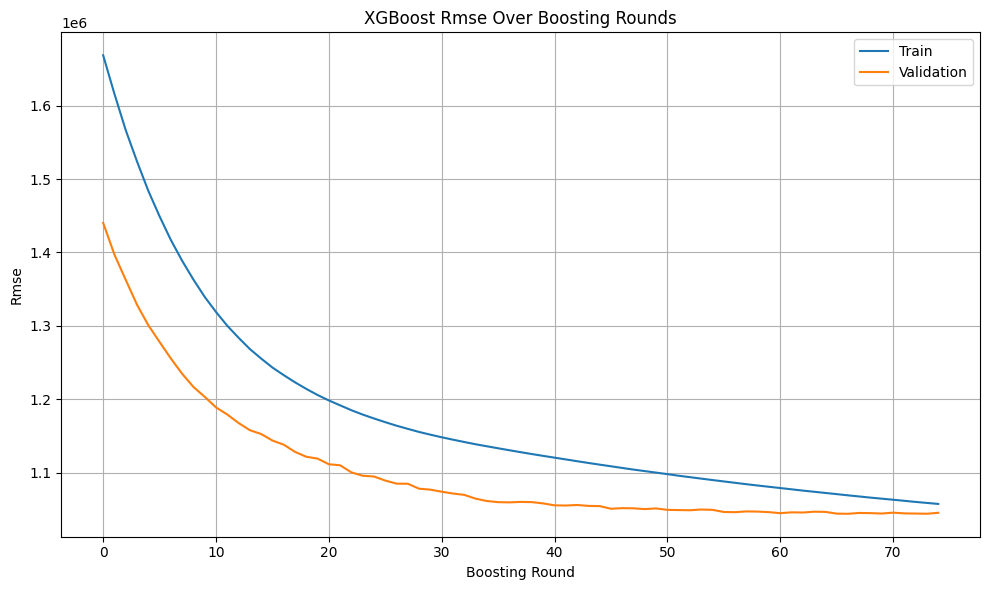

1413938.267217206 1011965.7024082568


In [61]:
#build baseline xgboost!!
#We also append baseline results!!




method = 'Baseline (XGBoost)'
params = {
    'objective': 'reg:squarederror',  # Regression with squared error
    'max_depth': 1,                   # Maximum depth of a tree
    'eta': 0.1,                       # Learning rate
    'eval_metric': 'rmse',           # RMSE as evaluation metric
    }
        
bst = train_xgboost(X_target_train, y_target_train, X_target_val, y_target_val, boosting_rounds=1000, params=params)
preds = test_xgboost(X_target_test, bst)
rmse = compute_rmse(preds, y_target_test)
mae = compute_mae(preds, y_target_test)

print(rmse, mae)


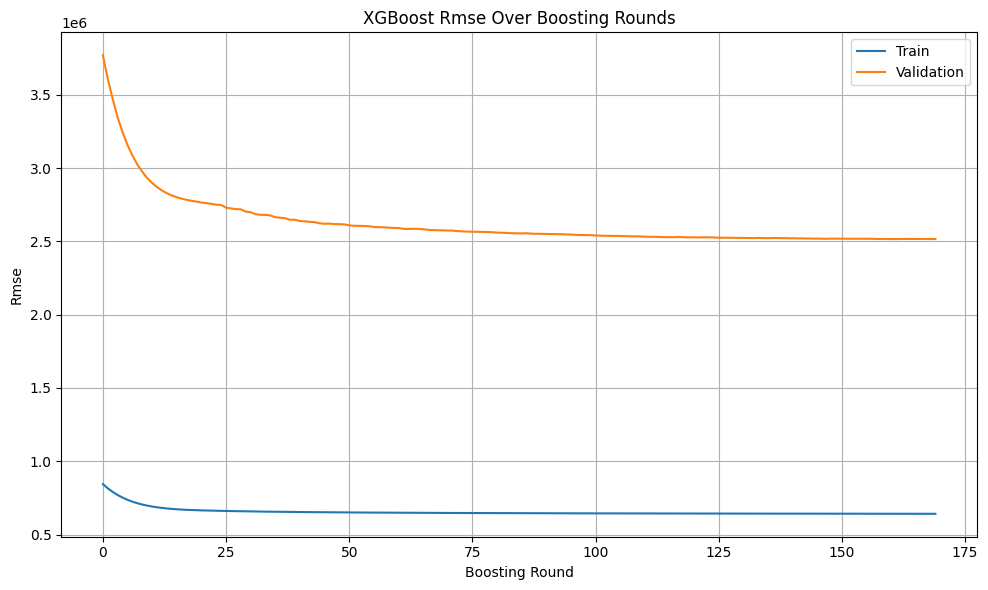

2778892.845852135 2343327.0672305045


In [62]:
#build baseline xgboost!!
#We also append baseline results!!
method = 'Baseline (XGBoost)'
params = {
    'objective': 'reg:squarederror',  # Regression with squared error
    'max_depth': 1,                   # Maximum depth of a tree
    'eta': 0.1,                       # Learning rate
    'eval_metric': 'rmse',           # RMSE as evaluation metric
    }
        
X_combined_train = np.concatenate((X_source_train, X_target_train))
y_combined_train = np.concatenate((y_source_train, y_target_train))
bst = train_xgboost(X_combined_train, y_combined_train, X_target_val, y_target_val, boosting_rounds=1000, params=params)
preds = test_xgboost(X_target_test, bst)
rmse = compute_rmse(preds, y_target_test)
mae = compute_mae(preds, y_target_test)

print(rmse, mae)

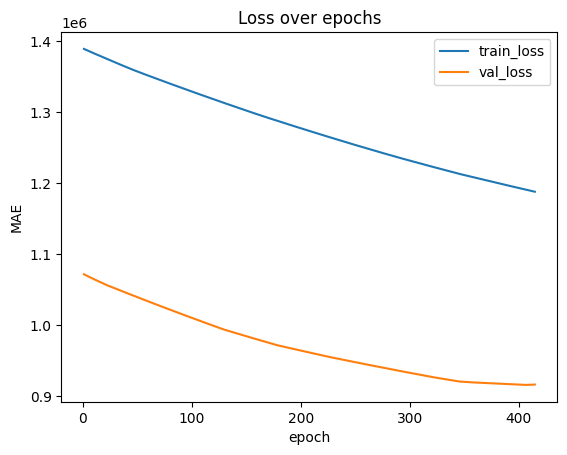

1792832.3823397707 1269568.13401397


In [ ]:

method = f'LSTransferTreeBoost'
fiter = LTransferTreeBoost(epochs=1000, v=0.001, source_tree_size=1, 
                            target_tree_size=1, alpha=1.0, decay=True, decay_factor = 1.0)
fiter.fit(X_target_train, y_target_train, X_source_train, y_source_train, val_x=X_target_val, val_y=y_target_val, early_stopping_rounds=8, show_curves = True)
rmse = fiter.evaluate(X_target_test, y_target_test, metric = 'rmse')
mae = fiter.evaluate(X_target_test, y_target_test, metric = 'mae')
print(rmse, mae)